In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

import xgboost as xgb
from wordcloud import WordCloud
import shap

In [10]:
df = pd.read_csv("/content/train_data.txt", sep=":::", engine="python",
                 names=["ID","TITLE","GENRE","PLOT"])
df.head()

,ID,TITLE,GENRE,PLOT
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his do...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous r...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fie...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends mee...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-re...


In [11]:
print(df.shape)
print(df.isnull().sum())

df['GENRE'].value_counts().head(10)

(54214, 4)
ID       0
TITLE    0
GENRE    0
PLOT     0
dtype: int64


,count
GENRE,
drama,13613
documentary,13096
comedy,7447
short,5073
horror,2204
thriller,1591
action,1315
western,1032
reality-tv,884


GENRE DISTRIBUTION

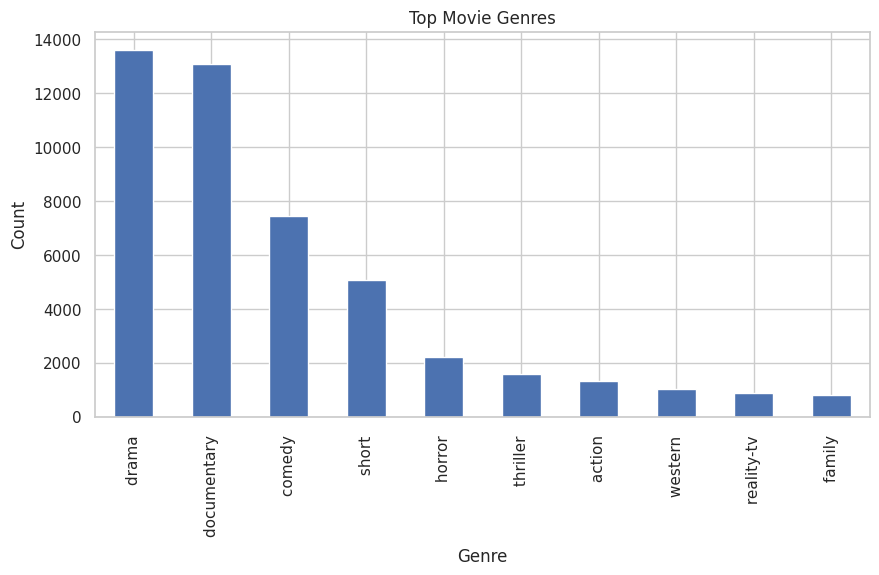

In [12]:
plt.figure(figsize=(10,5))

df['GENRE'].value_counts().head(10).plot(kind="bar")

plt.title("Top Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

PLOT LENGTH FEATURE

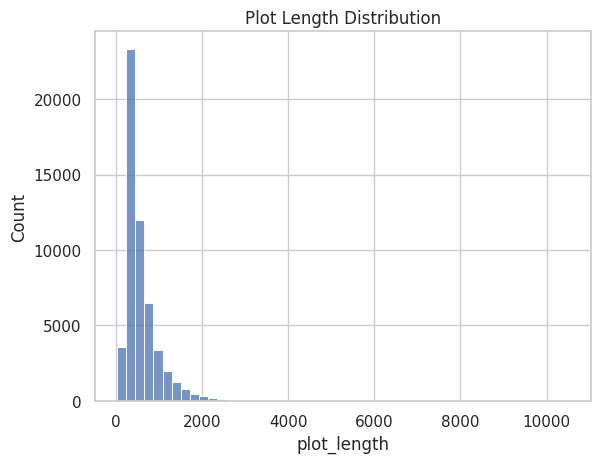

In [13]:
df['plot_length'] = df['PLOT'].apply(len)

sns.histplot(df['plot_length'], bins=50)

plt.title("Plot Length Distribution")

plt.show()

TF-IDF FEATURE ENGINEERING

In [14]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df['PLOT'])
y = df['GENRE']

TRAIN TEST SPLIT


In [15]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

MULTIPLE MODELS

In [16]:
models = {

    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC()

}

results = {}

for name,model in models.items():

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)

    results[name] = acc

    print(name)
    print(classification_report(y_test,pred))

Naive Bayes
               precision    recall  f1-score   support

      action        0.69      0.04      0.08       263
       adult        1.00      0.04      0.09       112
   adventure        0.53      0.06      0.12       139
   animation        0.00      0.00      0.00       104
   biography        0.00      0.00      0.00        61
      comedy        0.50      0.44      0.47      1443
       crime        0.00      0.00      0.00       107
 documentary        0.57      0.89      0.70      2659
       drama        0.46      0.83      0.59      2697
      family        0.00      0.00      0.00       150
     fantasy        0.00      0.00      0.00        74
   game-show        1.00      0.05      0.10        40
     history        0.00      0.00      0.00        45
      horror        0.74      0.30      0.43       431
       music        0.86      0.04      0.08       144
     musical        0.00      0.00      0.00        50
     mystery        0.00      0.00      0.00        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression
               precision    recall  f1-score   support

      action        0.54      0.24      0.33       263
       adult        0.88      0.21      0.33       112
   adventure        0.40      0.12      0.19       139
   animation        0.60      0.06      0.11       104
   biography        0.00      0.00      0.00        61
      comedy        0.52      0.59      0.56      1443
       crime        0.17      0.01      0.02       107
 documentary        0.67      0.86      0.75      2659
       drama        0.54      0.79      0.64      2697
      family        0.39      0.06      0.10       150
     fantasy        0.00      0.00      0.00        74
   game-show        0.94      0.40      0.56        40
     history        0.00      0.00      0.00        45
      horror        0.68      0.58      0.62       431
       music        0.68      0.45      0.54       144
     musical        1.00      0.02      0.04        50
     mystery        0.00      0.00      0.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SVM
               precision    recall  f1-score   support

      action        0.43      0.33      0.38       263
       adult        0.68      0.45      0.54       112
   adventure        0.37      0.25      0.30       139
   animation        0.32      0.14      0.20       104
   biography        0.00      0.00      0.00        61
      comedy        0.52      0.58      0.55      1443
       crime        0.15      0.05      0.07       107
 documentary        0.70      0.80      0.75      2659
       drama        0.56      0.69      0.62      2697
      family        0.28      0.14      0.19       150
     fantasy        0.00      0.00      0.00        74
   game-show        0.73      0.68      0.70        40
     history        0.00      0.00      0.00        45
      horror        0.62      0.62      0.62       431
       music        0.55      0.53      0.54       144
     musical        0.00      0.00      0.00        50
     mystery        0.07      0.02      0.03        56
     

MODEL COMPARISON

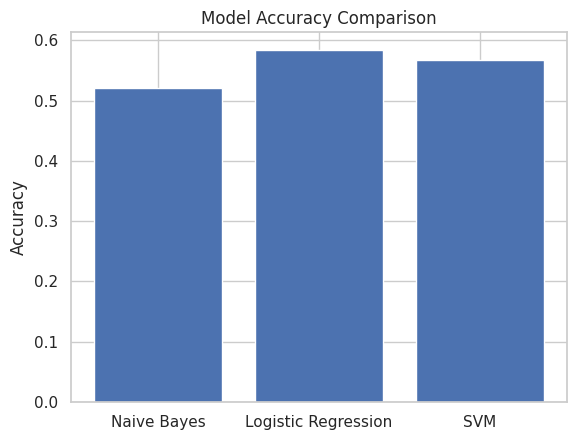

In [17]:
plt.bar(results.keys(),results.values())

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

CONFUSION MATRIX FOR BEST MODEL

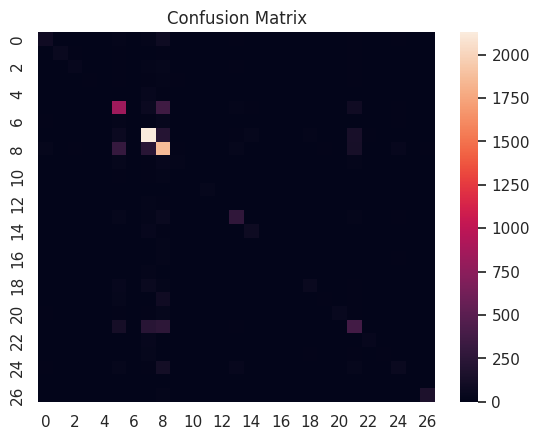

In [18]:
best_model = LinearSVC()

best_model.fit(X_train,y_train)

pred = best_model.predict(X_test)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm)

plt.title("Confusion Matrix")

plt.show()